# Importar datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Configuración de rutas
data_path = r"C:\Users\xXSrBiscuitXx\Documents\GitHub\ProjecteData\Equip_15\Data\RRHH_07102025_clean.parquet"

try:
    df = pd.read_parquet(data_path)
    print(f"✓ Dataset cargado correctamente: {df.shape[0]} filas, {df.shape[1]} columnas")
except Exception as e:
    print(f"✗ Error cargando el archivo: {e}")
    exit()

✓ Dataset cargado correctamente: 1056 filas, 26 columnas


# Preparar variables


In [3]:
# Hit target average
pd.set_option("display.max.columns", None)
# Calculamos la media de hit target de cada trabajador y nos quedamos con un solo registro por trabajador 
df['Hit_target_avg'] = df.groupby('ID')['Hit_target'].transform('mean')

# Disciplinary failure
df["AtLeastOneDiscFailure"] = df.groupby("ID")["Disciplinary_failure"].transform(lambda x: int(x.max()))

# Suma de horas
df["TotalHours"] = df.groupby("ID")["Absenteeism_hours"].transform("sum")

# Conteo faltas injustificadas
df["UnjustifiedCount"] = df.groupby("ID")["Reason_absence"].transform(lambda x: (x == "Ausencia injustificada").sum())

In [4]:
df = df.drop_duplicates(subset=["ID"], keep="last").reset_index(drop=True)
df


,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours,Reason_absence_numeric,Education_numeric,Month_absence_order,Day_week_order,Seasons_order,Hit_target_avg,AtLeastOneDiscFailure,TotalHours,UnjustifiedCount
0,6,Enfermedades del sistema musculoesquelético y ...,Abril,Jueves,Verano,189.0,29.0,13.0,33.0,246.288,91.0,0,High school,2,0,0,2,69.0,167.0,25.0,8.0,13,1,4.0,5,3,94.875000,0,72.0,0
1,16,Enfermedades del ojo y sus anexos,Junio,Miercoles,Verano,118.0,15.0,24.0,46.0,275.089,96.0,0,High school,2,1,1,0,75.0,175.0,25.0,8.0,7,1,6.0,4,3,97.500000,0,16.0,0
2,25,Consulta médica,Mayo,Jueves,Verano,235.0,16.0,8.0,32.0,237.656,99.0,0,Postgraduate,0,0,0,0,75.0,178.0,25.0,2.0,23,3,5.0,5,3,95.600000,0,42.0,0
3,12,"Lesiones, envenenamientos y consecuencias de o...",Julio,Viernes,Invierno,233.0,51.0,1.0,31.0,264.604,93.0,0,Graduate,1,1,0,8,68.0,178.0,21.0,2.0,19,2,7.0,6,1,96.142857,0,34.0,0
4,27,Consulta médica,Febrero,Viernes,Otono,184.0,42.0,7.0,27.0,302.585,99.0,0,High school,0,0,0,0,58.0,167.0,21.0,1.0,23,1,2.0,6,2,95.166667,0,25.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381,382,Consulta médica,Octubre,Lunes,Primavera,235.0,20.0,13.0,43.0,265.017,88.0,0,High school,1,1,0,0,106.0,167.0,38.0,2.0,23,1,10.0,2,4,88.000000,0,2.0,0
382,383,Enfermedades del sistema digestivo,Julio,Jueves,Invierno,189.0,29.0,13.0,33.0,239.554,97.0,0,High school,2,0,0,2,69.0,167.0,25.0,8.0,11,1,7.0,5,1,97.000000,0,8.0,0
383,384,Enfermedades del sistema respiratorio,Noviembre,Miercoles,Primavera,260.0,50.0,11.0,36.0,284.031,97.0,0,High school,4,1,0,0,65.0,168.0,23.0,8.0,10,1,11.0,4,4,97.000000,0,8.0,0
384,385,Examen de laboratorio,Junio,Lunes,Invierno,118.0,10.0,10.0,37.0,275.089,96.0,0,High school,0,0,0,0,83.0,172.0,28.0,3.0,25,1,6.0,2,1,96.000000,0,3.0,0


# Clustering

In [4]:
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

# Seleccionamos las columnas
dfClus = df[["Hit_target_avg", "AtLeastOneDiscFailure", "TotalHours", "UnjustifiedCount"]].copy()

# Escalamos solo las columnas numéricas
num_cols = ["Hit_target_avg", "TotalHours", "UnjustifiedCount"]
X_num = dfClus[num_cols].values
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Reconstruimos X agregando la columna categórica (falta disciplinaria)
X = np.hstack([X_num_scaled, dfClus[["AtLeastOneDiscFailure"]].values])

# Ahora la columna categórica es la última
cat_cols = [3]

# Entrenar K-Prototypes
kproto = KPrototypes(n_clusters=4, random_state=42, init='Huang')
clusters = kproto.fit_predict(X, categorical=cat_cols)

# Guardar clusters en el DataFrame
dfClus["cluster"] = clusters.astype(int)

print("\nIDs por cluster:")
for c in sorted(dfClus['cluster'].unique()):
    ids = dfClus[dfClus['cluster'] == c].index.tolist()
    print(f"\nCluster {c} ({len(ids)} empleados):")
    print(ids)

resumen = dfClus.groupby("cluster").agg({
    "Hit_target_avg": "mean",
    "AtLeastOneDiscFailure": "mean",   # será la proporción de 1s
    "TotalHours": "mean",
    "UnjustifiedCount": "mean",
    "cluster": "count"                 # cantidad de empleados por cluster
}).rename(columns={"cluster": "n_empleados"})
print(resumen)

# Imprimir cost
print("Cost del clustering:", kproto.cost_)

# Ver la distribución de clusters
print(dfClus["cluster"].value_counts())

# Opcional: mostrar centroides
print("Centroides:")
print(kproto.cluster_centroids_)


IDs por cluster:

Cluster 0 (13 empleados):
[5, 7, 9, 10, 13, 19, 21, 22, 23, 24, 25, 26, 29]

Cluster 1 (3 empleados):
[17, 27, 28]

Cluster 2 (37 empleados):
[8, 15, 31, 34, 45, 48, 49, 57, 61, 62, 64, 65, 66, 70, 71, 72, 73, 76, 77, 83, 86, 87, 88, 91, 94, 95, 96, 101, 104, 106, 111, 113, 118, 121, 124, 130, 132]

Cluster 3 (83 empleados):
[0, 1, 2, 3, 4, 6, 11, 12, 14, 16, 18, 20, 30, 32, 33, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 50, 51, 52, 53, 54, 55, 56, 58, 59, 60, 63, 67, 68, 69, 74, 75, 78, 79, 80, 81, 82, 84, 85, 89, 90, 92, 93, 97, 98, 99, 100, 102, 103, 105, 107, 108, 109, 110, 112, 114, 115, 116, 117, 119, 120, 122, 123, 125, 126, 127, 128, 129, 131, 133, 134, 135]
         Hit_target_avg  AtLeastOneDiscFailure  TotalHours  UnjustifiedCount  \
cluster                                                                        
0             94.621384               0.615385  270.230769          1.000000   
1             93.381217               1.000000  286.000000   

# Clustering treient gent que falta poc amb moltes hores

Preparar de nou les variables

In [53]:
df = pd.read_parquet(data_path)

# Hit target average
pd.set_option("display.max.columns", None)
# Calculamos la media de hit target de cada trabajador y nos quedamos con un solo registro por trabajador 
df['Hit_target_avg'] = df.groupby('ID')['Hit_target'].transform('mean')

# Disciplinary failure
df["AtLeastOneDiscFailure"] = df.groupby("ID")["Disciplinary_failure"].transform(lambda x: int(x.max()))

# Suma de horas
df["TotalHours"] = df.groupby("ID")["Absenteeism_hours"].transform("sum")

# Quantitat faltes
df['count_absenteeism'] = (
    (df['Absenteeism_hours'] != 0)  
    .groupby(df['ID'])              
    .transform('sum')               
)

# Conteo faltas injustificadas
df["UnjustifiedCount"] = df.groupby("ID")["Reason_absence"].transform(lambda x: (x == "Ausencia injustificada").sum())

Borrar gent que no volem y una sola entrada per id

In [ ]:
df = df.drop_duplicates(subset=["ID"], keep="last").reset_index(drop=True)

# Obtén los índices de quienes tienen más de 80 horas y faltan menos de 3 veces
idx = df[(df["TotalHours"] >= 80) & (df["count_absenteeism"] < 3)].index

# Bórralos
df = df.drop(idx)

ID                                      59
Reason_absence             Consulta dental
Month_absence                        Marzo
Day_week                           Viernes
Seasons                             Verano
Transportation_expense               225.0
Distance_Residence_Work               26.0
Service_time                           9.0
Age                                   28.0
Work_load_Average_day              343.253
Hit_target                            95.0
Disciplinary_failure                     0
Education                      High school
Son                                      1
Social_drinker                           0
Social_smoker                            0
Pet                                      2
Weight                                69.0
Height                               169.0
Body_mass_index                       24.0
Absenteeism_hours                      2.0
Reason_absence_numeric                  28
Education_numeric                        1
Month_absen

Clustering

In [37]:
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

# Seleccionamos las columnas
dfClus2 = df[["Hit_target_avg", "AtLeastOneDiscFailure", "TotalHours", "UnjustifiedCount"]].copy()

# Escalamos solo las columnas numéricas
num_cols = ["Hit_target_avg", "TotalHours", "UnjustifiedCount"]
X_num = dfClus2[num_cols].values
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Reconstruimos X agregando la columna categórica (falta disciplinaria)
X = np.hstack([X_num_scaled, dfClus2[["AtLeastOneDiscFailure"]].values])

# Ahora la columna categórica es la última
cat_cols = [3]

# Entrenar K-Prototypes
kproto = KPrototypes(n_clusters=4, random_state=42, init='Huang')
clusters = kproto.fit_predict(X, categorical=cat_cols)

# Guardar clusters en el DataFrame
dfClus2["cluster"] = clusters.astype(int)

resumen = dfClus2.groupby("cluster").agg({
    "Hit_target_avg": "mean",
    "AtLeastOneDiscFailure": "mean",   # será la proporción de 1s
    "TotalHours": "mean",
    "UnjustifiedCount": "mean",
    "cluster": "count"                 # cantidad de empleados por cluster
}).rename(columns={"cluster": "n_empleados"})
print(resumen)

# Imprimir cost
print("Cost del clustering:", kproto.cost_)

# Ver la distribución de clusters
print(dfClus2["cluster"].value_counts())

# Opcional: mostrar centroides
print("Centroides:")
print(kproto.cluster_centroids_)

         Hit_target_avg  AtLeastOneDiscFailure  TotalHours  UnjustifiedCount  \
cluster                                                                        
0             94.621384               0.615385  270.230769          1.000000   
1             93.381217               1.000000  286.000000          6.333333   
2             90.507407               0.138889    6.138889          0.055556   
3             96.510351               0.085366   13.463415          0.012195   

         n_empleados  
cluster               
0                 13  
1                  3  
2                 36  
3                 82  
Cost del clustering: 116.90038885001194
cluster
3    82
2    36
0    13
1     3
Name: count, dtype: int64
Centroides:
[[-0.00675025  2.39013133  0.68948125  1.        ]
 [-0.37195682  2.55564154  5.66674655  1.        ]
 [-1.21824101 -0.38171617 -0.19190948  0.        ]
 [ 0.54951585 -0.30483963 -0.23237505  0.        ]]


# Clustering Sociodemografico

In [5]:
df = pd.read_parquet(data_path)

## Cluster
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

# Agrupar por ID 
df_orig = df.groupby("ID").first()[[
    "Age", "Distance_Residence_Work", "Transportation_expense",
    "Son", "Education", "Social_drinker", "Social_smoker"
]].copy()

# Columnas numéricas y categóricas
num_cols = ["Age", "Distance_Residence_Work", "Transportation_expense", "Son"]
cat_cols = ["Education", "Social_drinker", "Social_smoker"]

# Preparamos un dataframe para K-Prototypes: escalamos SOLO las numéricas
df_kp = df_orig.copy()
scaler = StandardScaler()
df_kp[num_cols] = scaler.fit_transform(df_kp[num_cols])

# Aseguramos que las categóricas sean strings (requerido por k-prototypes)
for c in cat_cols:
    df_kp[c] = df_kp[c].astype(str)
# índices de columnas categóricas para k-prototypes
cat_idx = [df_kp.columns.get_loc(c) for c in cat_cols]

# Ejecutar K-Prototypes
kproto = KPrototypes(n_clusters=4, random_state=42, init='Cao')
clusters = kproto.fit_predict(df_kp.values, categorical=cat_idx)
df_orig["cluster"] = clusters

# Resumen numérico en unidades originales (medias)
cluster_num_summary = df_orig.groupby("cluster")[num_cols].mean()
print("Resumen numérico (unidades originales):")
print(cluster_num_summary.round(3))

# Resumen categórico: proporciones por cluster (por ejemplo % bebedores/fumadores y distribución de Education)
print("\nProporciones por cluster (categóricas):")
for c in cat_cols:
    prop = df_orig.groupby("cluster")[c].value_counts(normalize=True).unstack(fill_value=0)
    print(f"\n== {c} ==")
    print((prop*100).round(1))   # en porcentaje

# Modo (valor más frecuente) por cluster para las categóricas
mode_cat = df_orig.groupby("cluster")[cat_cols].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
print("\nModo (valor más frecuente) de las categóricas por cluster:")
print(mode_cat)

# Tamaño e IDs por cluster
print("\nTamaño por cluster:")
print(df_orig['cluster'].value_counts().sort_index())
print("\nIDs por cluster:")
for c in sorted(df_orig['cluster'].unique()):
    ids = df_orig[df_orig['cluster'] == c].index.tolist()
    print(f"\nCluster {c} ({len(ids)} empleados):")
    print(ids)


## Centroides y score
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np
# 1) Centroides interpretables
def mode_series(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

centroids_num = df_orig.groupby("cluster")[num_cols].mean()           # medias en unidades originales
centroids_cat = df_orig.groupby("cluster")[cat_cols].agg(mode_series) # moda de categóricas
centroids_readable = pd.concat([centroids_num, centroids_cat], axis=1)

print("\nCentroides interpretables (numérico = media; categórico = moda):")
print(centroids_readable.round(3))

# 2) Silhouette score - Opción A: SOLO numéricas escaladas
# usamos el scaler que ya tienes (entrenado sobre num_cols)
X_num_scaled = scaler.transform(df_orig[num_cols])   # df_orig tiene las num en unidades originales
sil_num = silhouette_score(X_num_scaled, df_orig['cluster'])
print(f"\nSilhouette (solo numéricas escaladas): {sil_num:.4f}")

# 3) Silhouette score - Opción B: numéricas + categóricas (One-Hot)
# Preparamos ColumnTransformer: escala numéricas y one-hot para categóricas
ct = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ],
    remainder="drop"
)

# Nota: usamos df_orig (unidades originales); ColumnTransformer hará el scaling
X_mixed = ct.fit_transform(df_orig[num_cols + cat_cols])
sil_mixed = silhouette_score(X_mixed, df_orig['cluster'])
print(f"Silhouette (numéricas + one-hot categóricas): {sil_mixed:.4f}")

# 4) Tamaño por cluster y muestra de centroides internos de kproto (opcional)
print("\nTamaño por cluster:")
print(df_orig['cluster'].value_counts().sort_index())

# kproto.cluster_centroids_ existe pero tiene formato interno: 
# numéricas (centroides continuos) y categóricas (modas como índices)
try:
    kp_centroids = kproto.cluster_centroids_
    print("\nCentroides internos reportados por kproto (formato interno):")
    print(kp_centroids)
except Exception:
    pass

# 5) Mensajes interpretativos rápidos
print("""
NOTAS:
- Silhouette (A) usa sólo numéricas: rápido, pero ignora info categórica.
- Silhouette (B) usa numéricas + one-hot: más representativo para datos mixtos,
  aunque la dimensionalidad sube y puede afectar el valor.
- Interpretación de Silhouette: >0.5 bueno, 0.2-0.5 moderado, <0.2 débil.
- Los centroides 'readable' muestran la media (num) y la moda (cat) por cluster,
  úsalos para nominar/explicar cada cluster.
""")

# Imprimir cost
print("Cost del clustering:", kproto.cost_)

Resumen numérico (unidades originales):
            Age  Distance_Residence_Work  Transportation_expense    Son
cluster                                                                
0        37.739                   50.884                 188.565  0.058
1        44.698                   21.519                 224.075  1.321
2        31.734                   19.811                 193.846  0.706
3        33.382                   41.059                 304.794  2.691

Proporciones por cluster (categóricas):

== Education ==
Education  Graduate  High school  Master/Doctor  Postgraduate
cluster                                                      
0               5.8         94.2            0.0           0.0
1               9.4         85.8            4.7           0.0
2               5.6         69.9            0.0          24.5
3               0.0        100.0            0.0           0.0

== Social_drinker ==
Social_drinker     0     1
cluster                   
0                2.9  

# Clustering Molt més personal


In [6]:
df = pd.read_parquet(data_path)

## Cluster
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

# Agrupar por ID 
df_personal = df.groupby("ID").first()[[
    "Age", "Distance_Residence_Work", "Transportation_expense",
    "Son", "Education", "Social_drinker", "Social_smoker", "Body_mass_index", "Service_time", "Height", "Weight", "Pet"
]].copy()

# Columnas numéricas y categóricas
num_cols = ["Age", "Distance_Residence_Work", "Transportation_expense", "Son", "Service_time", "Height", "Weight", "Body_mass_index","Pet"]
cat_cols = ["Education", "Social_drinker", "Social_smoker"]

# Preparamos un dataframe para K-Prototypes: escalamos SOLO las numéricas
df_kp = df_personal.copy()
scaler = StandardScaler()
df_kp[num_cols] = scaler.fit_transform(df_kp[num_cols])

# Aseguramos que las categóricas sean strings (requerido por k-prototypes)
for c in cat_cols:
    df_kp[c] = df_kp[c].astype(str)
# índices de columnas categóricas para k-prototypes
cat_idx = [df_kp.columns.get_loc(c) for c in cat_cols]

# Ejecutar K-Prototypes
kproto = KPrototypes(n_clusters=4, random_state=42, init='Cao')
clusters = kproto.fit_predict(df_kp.values, categorical=cat_idx)
df_personal["cluster"] = clusters

# Resumen numérico en unidades originales (medias)
cluster_num_summary = df_personal.groupby("cluster")[num_cols].mean()
print("Resumen numérico (unidades originales):")
print(cluster_num_summary.round(3))

# Resumen categórico: proporciones por cluster (por ejemplo % bebedores/fumadores y distribución de Education)
print("\nProporciones por cluster (categóricas):")
for c in cat_cols:
    prop = df_personal.groupby("cluster")[c].value_counts(normalize=True).unstack(fill_value=0)
    print(f"\n== {c} ==")
    print((prop*100).round(1))   # en porcentaje

# Modo (valor más frecuente) por cluster para las categóricas
mode_cat = df_personal.groupby("cluster")[cat_cols].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
print("\nModo (valor más frecuente) de las categóricas por cluster:")
print(mode_cat)

# Tamaño e IDs por cluster
print("\nTamaño por cluster:")
print(df_personal['cluster'].value_counts().sort_index())
print("\nIDs por cluster:")
for c in sorted(df_personal['cluster'].unique()):
    ids = df_personal[df_personal['cluster'] == c].index.tolist()
    print(f"\nCluster {c} ({len(ids)} empleados):")
    print(ids)

    # Imprimir cost
print("Cost del clustering:", kproto.cost_)

Resumen numérico (unidades originales):
            Age  Distance_Residence_Work  Transportation_expense    Son  \
cluster                                                                   
0        30.877                   35.236                 261.085  1.906   
1        40.486                   21.352                 218.276  1.629   
2        37.589                   19.938                 206.411  0.491   
3        38.349                   50.905                 182.492  0.000   

         Service_time   Height  Weight  Body_mass_index    Pet  
cluster                                                         
0               9.330  169.434  68.642           23.858  1.811  
1              14.457  175.210  91.743           29.990  0.905  
2              11.268  172.795  71.321           23.857  0.179  
3              18.349  170.063  89.603           31.159  0.063  

Proporciones por cluster (categóricas):

== Education ==
Education  Graduate  High school  Master/Doctor  Postgraduate

# Diferencies per rendiment entre clusters


Kruskal–Wallis test amb cluster sociodemografic: H=9.234, p-value=0.0263
Estadístiques descriptives de Hit_target per cluster:
          mean   std  count
cluster                    
0        95.19  4.41     69
1        94.61  4.02    106
2        94.80  2.80    143
3        94.08  3.66     68


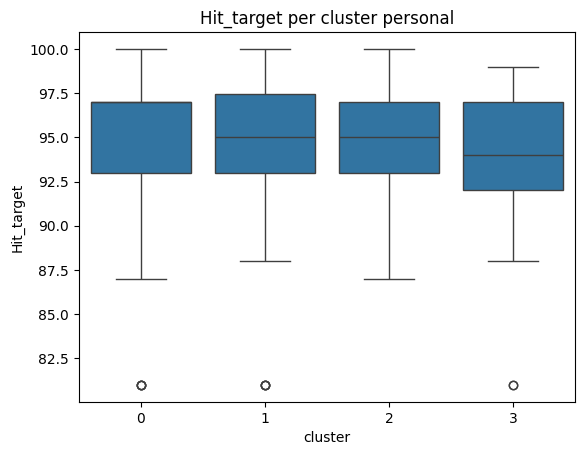


Kruskal–Wallis test amb cluster personal: H=9.386, p-value=0.0246
Estadístiques descriptives de Hit_target per cluster:
          mean   std  count
cluster                    
0        94.42  3.18    106
1        94.60  3.77    105
2        94.71  3.33    112
3        95.26  4.53     63


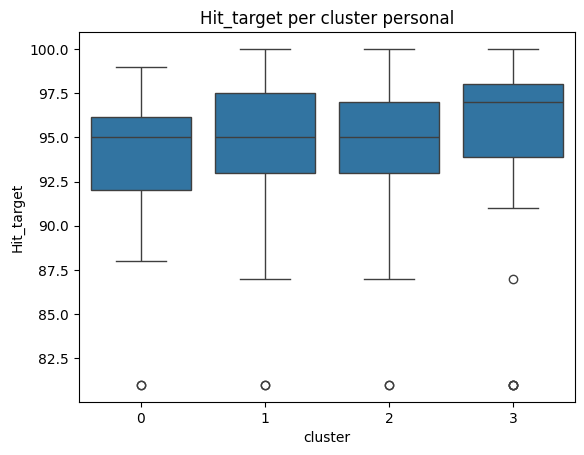

In [7]:
from scipy.stats import kruskal

#------------------------------------------------------------------------------------------ Amb cluster sociodemogràfic:

# Afegim la mitjana de Hit_target per ID
hit_mean = df.groupby("ID")["Hit_target"].mean()

# Afegim-la al df_orig (que té un sol registre per ID)
if "Hit_target" in df_orig.columns:
    df_orig = df_orig.drop(columns="Hit_target")

df_orig = df_orig.join(hit_mean)

# Llista de sèries de Hit_target per cada cluster
groups = [df_orig[df_orig["cluster"] == c]["Hit_target"].dropna() for c in sorted(df_orig["cluster"].unique())]

stat, p = kruskal(*groups)
print(f"\nKruskal–Wallis test amb cluster sociodemografic: H={stat:.3f}, p-value={p:.4f}")

# Mitjana, desviació estàndard i nombre de casos per cluster
print("Estadístiques descriptives de Hit_target per cluster:")
print(df_orig.groupby("cluster")["Hit_target"].agg(['mean', 'std', 'count']).round(2))

sns.boxplot(x="cluster", y="Hit_target", data=df_orig)
plt.title("Hit_target per cluster personal")
plt.show()

#------------------------------------------------------------------------------------------ Amb cluster més personal:

# Afegim la mitjana de Hit_target per ID
hit_mean = df.groupby("ID")["Hit_target"].mean()

# Afegim-la al df_orig (que té un sol registre per ID)
if "Hit_target" in df_personal.columns:
    df_personal = df_personal.drop(columns="Hit_target")

df_personal = df_personal.join(hit_mean)

# Llista de sèries de Hit_target per cada cluster
groups = [df_personal[df_personal["cluster"] == c]["Hit_target"].dropna() for c in sorted(df_personal["cluster"].unique())]

stat, p = kruskal(*groups)
print(f"\nKruskal–Wallis test amb cluster personal: H={stat:.3f}, p-value={p:.4f}")

# Mitjana, desviació estàndard i nombre de casos per cluster
print("Estadístiques descriptives de Hit_target per cluster:")
print(df_personal.groupby("cluster")["Hit_target"].agg(['mean', 'std', 'count']).round(2))

sns.boxplot(x="cluster", y="Hit_target", data=df_personal)
plt.title("Hit_target per cluster personal")
plt.show()

# Quins grups difereixen

In [8]:
import scikit_posthocs as sp

# Test post-hoc de Dunn amb correcció Bonferroni
posthoc = sp.posthoc_dunn(df_orig, val_col='Hit_target', group_col='cluster', p_adjust='bonferroni')

print("Post-hoc Dunn test (p-values ajustats):")
print(posthoc.round(4))

Post-hoc Dunn test (p-values ajustats):
        0       1       2       3
0  1.0000  0.5171  0.0983  0.0232
1  0.5171  1.0000  1.0000  0.8511
2  0.0983  1.0000  1.0000  1.0000
3  0.0232  0.8511  1.0000  1.0000
